# Import and Datasets

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os


In [4]:
!rm -rf animals10small.zip animals10small
!gdown -q 1Do8SXKm4rmXW-phHlejV-udLfhSyYgKk -O animals10small.zip
!unzip -qq animals10small.zip


In [5]:
DATA_DIR = "./animals10small/data"

def show_image(image, title=""):
    plt.figure()
    if(image.ndim == 3):
      plt.imshow(image)
    elif (image.ndim == 2):
      plt.imshow(image, cmap="gray")
    else:
      raise Exception("Invalid image dimension")
    plt.axis("off")
    plt.title(title)

dirs = os.listdir(DATA_DIR)
[dir for dir in dirs if os.path.isdir(os.path.join(DATA_DIR, dir))]

filename = os.path.join(DATA_DIR, "cat/10.jpeg")
bgr = cv2.imread(filename)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

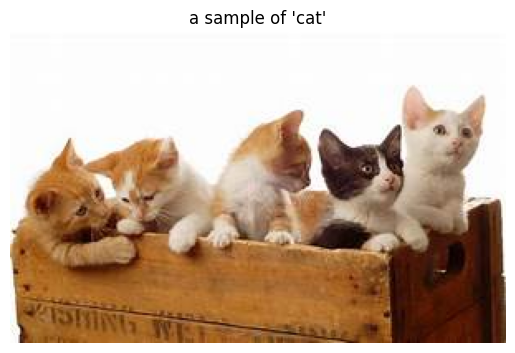

In [6]:
show_image(rgb, "a sample of 'cat'")

# Broadcasting


## Case 1

## Case 1.1: vector and scalar

In [7]:
N = 5
x = np.random.randint(0, 10, size=(N, ))
x

array([4, 4, 3, 0, 9])

In [9]:
x + 4 # vector + scalar: make temp vector v = [4]*5 ; then add element-wise

array([ 8,  8,  7,  4, 13])

In [11]:
[4]*5

[4, 4, 4, 4, 4]

In [10]:
x + np.array([4]*5)

array([ 8,  8,  7,  4, 13])

## Case 1.2: Higher dim vs scalar

In [12]:
N, M = 4, 3
X = np.random.randint(0, 10, (N, M))
X

array([[4, 7, 9],
       [9, 6, 6],
       [1, 7, 1],
       [8, 1, 6]])

In [13]:
X * 4

array([[16, 28, 36],
       [36, 24, 24],
       [ 4, 28,  4],
       [32,  4, 24]])

# Case 2: Matrix vs vector

## Case 2.1: (N, M) vs (M, ) => Fine

In [18]:
N, M = 4, 3
X = np.random.randint(0, 10, (N, M))
v = np.random.randint(0, 10, (M, ))
print("X: "); print(X)
print("v: "); print(v)
print()
print("X.shape: ", X.shape)
print("v.shape: ", v.shape)

X: 
[[1 2 6]
 [6 5 5]
 [7 6 8]
 [3 3 6]]
v: 
[5 5 4]

X.shape:  (4, 3)
v.shape:  (3,)


In [19]:
X + v #OK, no error

array([[ 6,  7, 10],
       [11, 10,  9],
       [12, 11, 12],
       [ 8,  8, 10]])

## Case 2.2: (N, M) vs (N, ) => Fail

In [20]:
N, M = 4, 3
X = np.random.randint(0, 10, (N, M))
v = np.random.randint(0, 10, (N, ))
print("X: "); print(X)
print("v: "); print(v)
print()
print("X.shape: ", X.shape)
print("v.shape: ", v.shape)

X: 
[[0 8 8]
 [7 6 5]
 [1 7 0]
 [8 8 8]]
v: 
[1 0 4 1]

X.shape:  (4, 3)
v.shape:  (4,)


In [21]:
X + v # error

ValueError: operands could not be broadcast together with shapes (4,3) (4,) 

In [23]:
v.reshape(-1, 1).shape

(4, 1)

In [22]:
X + v.reshape(-1, 1) # (-1, 1) = 1 columns and num-arrows is determined auto

array([[ 1,  9,  9],
       [ 7,  6,  5],
       [ 5, 11,  4],
       [ 9,  9,  9]])

# keepdims and broadcast

## Motivation
* Functions that reduce the data:
  * sum
  * mean
  * std
  * avarage
  * ... statatical functions

In [24]:
N, M = 4, 3
X = np.random.randint(0, 10, (N, M))
print("X: "); print(X)
print("X.shape: ", X.shape)

X: 
[[7 6 6]
 [3 1 0]
 [3 5 3]
 [0 9 8]]
X.shape:  (4, 3)


In [25]:
X.mean() # => one global mean

np.float64(4.25)

In [26]:
X.mean(axis=0) # mean along axis=0

array([3.25, 5.25, 4.25])

In [27]:
X.mean(axis=0).shape

(3,)

In [28]:
X.mean(axis=0, keepdims=True) # mean along axis=0

array([[3.25, 5.25, 4.25]])

In [30]:
X.mean(axis=0, keepdims=True).shape

(1, 3)

## Define softmax

In [31]:
N, M = 4, 3
Z = np.random.randint(0, 10, (N, M))
Z

array([[4, 2, 2],
       [1, 6, 1],
       [0, 2, 2],
       [8, 2, 9]])

In [35]:
Max = Z.max(axis=-1, keepdims=True)
print("Max.shape: ", Max.shape)
ZM = Z - Max
print("ZM.shape: ", ZM.shape)
EZM = np.exp(ZM)
print("EM.shape: ", EZM.shape)
EZM_sum = EZM.sum(axis=-1, keepdims=True)
print("EZM_sum.shape: ", EZM_sum.shape)
P = EZM / EZM_sum
print("P.shape: ", P.shape)

Max.shape:  (4, 1)
ZM.shape:  (4, 3)
EM.shape:  (4, 3)
EZM_sum.shape:  (4, 1)
P.shape:  (4, 3)


In [36]:
def softmax(Z, axis=-1):
  Max = Z.max(axis=axis, keepdims=True)
  ZM = Z - Max
  EZM = np.exp(ZM)
  EZM_sum = EZM.sum(axis=axis, keepdims=True)
  return EZM / EZM_sum

In [37]:
N, M = 4, 3
Z = np.random.randint(0, 10, (N, M))
print("Z: "); print(Z)
print("Z.shape: ", Z.shape)
P = softmax(Z)
print("P: "); print(P)
print("P.shape: ", P.shape)
print("Sum along rows: "); print(P.sum(axis=-1))
#

Z: 
[[3 3 2]
 [5 2 1]
 [7 9 3]
 [3 7 1]]
Z.shape:  (4, 3)
P: 
[[0.4223188  0.4223188  0.1553624 ]
 [0.93623955 0.04661262 0.01714783]
 [0.11894324 0.87887824 0.00217852]
 [0.01794253 0.97962921 0.00242826]]
P.shape:  (4, 3)
Sum along rows: 
[1. 1. 1. 1.]


# eisum function

## reduce tensors

In [38]:
N, M = 4, 3
a = np.random.randint(0, 10, (N, ))
b = np.random.randint(0, 10, (M, ))
X = np.random.randint(0, 10, (N, M))
print("X: "); print(X)
print("X.shape: ", X.shape)
print("a: "); print(a)
print("b.shape: ", b.shape)

X: 
[[5 0 0]
 [3 5 1]
 [0 2 7]
 [4 5 3]]
X.shape:  (4, 3)
a: 
[1 8 7 2]
b.shape:  (3,)


In [39]:
a.sum()

np.int64(18)

In [40]:
b.sum()

np.int64(22)

In [41]:
X.sum()

np.int64(35)

In [42]:
np.einsum("i->", a)

np.int64(18)

In [43]:
np.einsum("i->", b)

np.int64(22)

In [44]:
np.einsum("ij->", X) # sum all

np.int64(35)

In [45]:
np.einsum("ij->i", X) # sum rows

array([ 5,  9,  9, 12])

In [46]:
np.einsum("ij->j", X) # sum cols

array([12, 12, 11])

In [47]:
X

array([[5, 0, 0],
       [3, 5, 1],
       [0, 2, 7],
       [4, 5, 3]])

## dot-product

In [48]:
N, M = 4, 3
a = np.random.randint(0, 10, (N, ))
b = np.random.randint(0, 10, (M, ))
X = np.random.randint(0, 10, (N, M))
print("X: "); print(X)
print("X.shape: ", X.shape)
print("a: "); print(a)
print("b.shape: ", b.shape)

X: 
[[8 4 1]
 [4 1 4]
 [9 5 4]
 [3 2 8]]
X.shape:  (4, 3)
a: 
[8 1 3 7]
b.shape:  (3,)


In [50]:
np.einsum("i,i->", a, a)

np.int64(123)

In [51]:
(a*a).sum()

np.int64(123)

In [52]:
np.einsum("i,i->i", a, a)

array([64,  1,  9, 49])

In [54]:
a*a

array([64,  1,  9, 49])

### einsum with matrix vs vector

In [60]:
X*a.reshape(-1, 1)

array([[64, 32,  8],
       [ 4,  1,  4],
       [27, 15, 12],
       [21, 14, 56]])

In [62]:
(X*a.reshape(-1, 1)).sum(axis=0)

array([116,  62,  80])

In [57]:
a

array([8, 1, 3, 7])

In [67]:
np.einsum("ij, i->", X, a)

np.int64(258)

In [68]:
np.einsum("ij, j->i", X, b)

array([63, 33, 84, 51])

In [69]:
X@b

array([63, 33, 84, 51])

In [70]:
X.T@a

array([116,  62,  80])

### einsum: linear transform
* ```Y = WX + b```


In [78]:
B = 10 # batchsize
Nin, Nout = 4, 3
bias = np.random.randint(0, 10, (Nout, ))
W = np.random.randint(0, 10, (Nin, Nout))
X = np.random.randint(0, 10, (B, Nin))
print("W.shape: ", W.shape)
print("bias.shape: ", bias.shape)
print("X.shape: ", X.shape)


W.shape:  (4, 3)
bias.shape:  (3,)
X.shape:  (10, 4)


In [82]:
Y = X@W + bias
print("Y.shape: ", Y.shape)
print("Y: "); print(Y)

Y.shape:  (10, 3)
Y: 
[[ 61  81  70]
 [ 42 106  78]
 [ 84 124 114]
 [ 65  95  76]
 [ 53  83  98]
 [ 49 120 101]
 [ 51 103  61]
 [ 51  67  87]
 [ 18  43  54]
 [ 60  91  62]]


In [81]:
np.einsum("ij,ki->kj", W, X) + bias # X@W + bias

array([[ 61,  81,  70],
       [ 42, 106,  78],
       [ 84, 124, 114],
       [ 65,  95,  76],
       [ 53,  83,  98],
       [ 49, 120, 101],
       [ 51, 103,  61],
       [ 51,  67,  87],
       [ 18,  43,  54],
       [ 60,  91,  62]])

### einsum in Transformer

In [87]:
B = 10
Nq, Nk = 32, 64
heads = 8
head_dim = 128

Q = np.random.normal(0, 1, (N, heads, Nq, head_dim))
K = np.random.normal(0, 1, (N, heads, Nk, head_dim))
print("Q.shape: ", Q.shape)
print("K.shape: ", K.shape)

Q.shape:  (4, 8, 32, 128)
K.shape:  (4, 8, 64, 128)


In [91]:
A = np.einsum("ijlm,ijkm->ijlk", Q, K)
A.shape


(4, 8, 32, 64)

In [92]:
A.mean(axis=1).shape # averaged on all attention matrix for each sample
# (B, Nq, Nk)

(4, 32, 64)

## distance between two sets of points

In [94]:
Na, Nb = 4, 5
A = np.random.normal((-1,-1), 1, (Na, 2))
B = np.random.normal((2,2), 1, (Nb, 2))
print("A.shape: ", A.shape)
print("B.shape: ", B.shape)

A.shape:  (4, 2)
B.shape:  (5, 2)


In [103]:
np.sqrt(((A[:, None, :] - B[None, :, :])**2).sum(axis=-1))

array([[5.75469527, 5.6560117 , 6.01027402, 3.94046256, 3.86622605],
       [5.13422403, 5.01151217, 5.17858314, 3.1551572 , 3.09918163],
       [2.9703791 , 3.06339739, 5.00219023, 3.38165674, 3.21039592],
       [6.4421856 , 6.3368488 , 6.56902872, 4.54880542, 4.48785915]])